# Donor Behavioral Factor Analysis — Simple v1

**Question:** among a deliberately small set of practical donor behaviors, what underlying dimensions tend to move together?

This notebook intentionally does **one exploratory factor analysis (EFA)** rather than trying many models.

### Design
1. Load a curated behavioral feature set.
2. Sanity-check missingness and residual correlation with total gift count.
3. Use parallel analysis to suggest the number of factors.
4. Fit one varimax-rotated factor analysis.
5. Show compact factor summaries + a feature audit.

**Population-filter flexibility:** `MIN_GIFTS_FIELD` controls which gift-count field determines eligibility, while `TOTAL_GIFTS_FIELD` separately controls the volume-leakage audit. This lets you filter, for example, on Green gifts without redefining the audit of whether features are merely tracking total giving volume.

**Window note:** the current source build uses explicit `_24m` names.


In [1]:
from __future__ import annotations

from pathlib import Path
from html import escape
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print(f"pandas={pd.__version__} | numpy={np.__version__}")


pandas=2.3.2 | numpy=1.26.4


## 1 — Configuration

This is the main cell to edit.

- `MIN_GIFTS_FIELD` controls **eligibility**. Default: `n_gifts_green_24m`.
- `TOTAL_GIFTS_FIELD` controls the **volume-leakage audit**. Default: `n_gifts_24m`.
- To switch back to all project gifts for eligibility, set `MIN_GIFTS_FIELD = "n_gifts_24m"`.
- `EXCLUDE_TEACHERS` is a one-line population sensitivity.
- Leave `N_FACTORS_OVERRIDE = None` to use the parallel-analysis recommendation. Set it to `8` (or another number) when you want to inspect a specific solution.
- Edit `FEATURE_GROUPS` to add/remove practical behaviors. The group labels are organizational only; they do not weight the factor analysis.


In [2]:
DATA_DIR = Path("/Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data")
FEATURES_PATH = DATA_DIR / "clustering_features_20260801_w24m.csv"

# Population controls.
MIN_GIFTS = 4
MIN_GIFTS_FIELD = "n_gifts_green_24m"   # eligibility filter; use "n_gifts_24m" for all project gifts
TOTAL_GIFTS_FIELD = "n_gifts_24m"       # volume-leakage audit stays tied to total project-gift observations
EXCLUDE_TEACHERS = True

# Other source/control fields.
SITE_DATA_FIELD = "has_site_data_24m"
PROJECT_COST_COVERAGE_FIELD = "coverage_project_cost_24m"

# Factor-analysis controls.
N_FACTORS_OVERRIDE = None   # e.g. 8
RANDOM_STATE = 20260825
PARALLEL_ITERATIONS = 75
PARALLEL_SAMPLE_N = 10_000
LOADING_DISPLAY_THRESHOLD = 0.30
CROSS_LOADING_THRESHOLD = 0.30
PROJECT_COST_COVERAGE_FLOOR = 0.50

FEATURE_GROUPS = {
    "giving_rhythm": [
        "n_active_months_24m",
        "gifts_per_active_month_24m",
    ],
    "relationship": [
        #"entropy_teacher_norm_24m",
        "share_gifts_repeat_teacher_24m",
        "entropy_school_norm_24m",
        #"share_gifts_repeat_school_24m",
    ],
    "amount_style": [
        "modal_amount_share_24m",
        "share_gifts_round_amount_24m",
        "median_gift_amount_24m",
    ],
    "funding_posture": [
        "median_gift_to_project_cost_ratio_24m",
        #"share_gifts_over_half_project_cost_24m",
        "share_gifts_first_money_in_24m",
        "share_gifts_closed_project_24m",
    ],
    "choice_breadth": [
        "entropy_category_norm_24m",
        #"entropy_channel_norm_24m",
    ],
    "platform_support": [
        "avg_optional_donation_rate_24m",
        #"share_gifts_with_optional_donation_24m",
    ],
    "match_response": [
        "share_gifts_with_match_24m",
        #"mean_match_excess_24m",
    ],
    "timing": [
        "entropy_gift_month_norm_24m",
        "share_gifts_big_event_24m",
    ],
    "site_engagement": [
        "days_with_site_activity_24m",
        "search_visits_day_total_24m",
        #"sharing_active_months_24m",
    ],
    "identity": [
        #"is_teacher",
        #"is_teacher_referred",
    ],
}

# Explicit transforms only. Shares/entropies stay on their native scale before standardization.
LOG1P_FIELDS = {
    "gifts_per_active_month_24m",
    "median_gift_amount_24m",
    "median_gift_to_project_cost_ratio_24m",
    "mean_match_excess_24m",
    "days_with_site_activity_24m",
    "search_visits_day_total_24m",
}

PROJECT_COST_FIELDS = {
    "median_gift_to_project_cost_ratio_24m",
    "share_gifts_over_half_project_cost_24m",
}

# Counts of recorded site activity. If a donor has no site rows, zero is cleaner
# than median-imputing average site activity.
SITE_COUNT_FIELDS = {
    "days_with_site_activity_24m",
    "search_visits_day_total_24m",
}

DEMO_IF_FEATURE_FILE_MISSING = True

FEATURES_SELECTED = [f for fields in FEATURE_GROUPS.values() for f in fields]
if len(FEATURES_SELECTED) != len(set(FEATURES_SELECTED)):
    raise ValueError("A feature appears in more than one FEATURE_GROUPS entry.")

feature_plan = pd.DataFrame(
    [
        {"concept": group, "feature": f, "transform": "log1p" if f in LOG1P_FIELDS else "none"}
        for group, fields in FEATURE_GROUPS.items()
        for f in fields
    ]
)
display(feature_plan.style.hide(axis="index").set_caption(f"Selected inputs: {len(FEATURES_SELECTED)} features"))

print(f"Eligibility: {MIN_GIFTS_FIELD} >= {MIN_GIFTS}")
print(f"Volume audit: {TOTAL_GIFTS_FIELD}")


concept,feature,transform
giving_rhythm,n_active_months_24m,none
giving_rhythm,gifts_per_active_month_24m,log1p
relationship,share_gifts_repeat_teacher_24m,none
relationship,entropy_school_norm_24m,none
amount_style,modal_amount_share_24m,none
amount_style,share_gifts_round_amount_24m,none
amount_style,median_gift_amount_24m,log1p
funding_posture,median_gift_to_project_cost_ratio_24m,log1p
funding_posture,share_gifts_first_money_in_24m,none
funding_posture,share_gifts_closed_project_24m,none


Eligibility: n_gifts_green_24m >= 4
Volume audit: n_gifts_24m


## 2 — Load + sanity-check

The audit is intentionally compact. The most useful column is `rho_vs_total_gifts`: Spearman correlation with `TOTAL_GIFTS_FIELD`.

A large value does **not automatically disqualify** a feature, but it tells you that the feature may still be partly measuring observation volume. This is the check to watch for the entropy variables.

The notebook validates every required field before loading the full data, so a renamed or missing field fails with a short, explicit message.


In [3]:
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def make_demo_data(n=5000, seed=RANDOM_STATE):
    # Synthetic data exists only so this shared notebook can execute end-to-end.
    # The real CSV automatically takes precedence on your machine.
    rng = np.random.default_rng(seed)
    F = rng.normal(size=(n, 9))

    d = pd.DataFrame({
        "donor_id": [f"demo_{i:05d}" for i in range(n)],
        "cluster_eligible": 1,
        "is_teacher": (rng.random(n) < 0.12).astype(int),
        SITE_DATA_FIELD: (rng.random(n) < 0.72).astype(int),
        PROJECT_COST_COVERAGE_FIELD: np.clip(rng.normal(0.90, 0.12, n), 0, 1),
    })

    gift_intensity = np.exp(1.0 + 0.45 * F[:, 0] + rng.normal(0, 0.25, n))
    total_gifts = np.maximum(MIN_GIFTS, np.rint(4 + gift_intensity).astype(int))
    green_share = np.clip(_sigmoid(-0.15 + 0.35 * F[:, 0] + rng.normal(0, 0.55, n)), 0.15, 1.0)
    green_gifts = np.maximum(0, np.rint(total_gifts * green_share).astype(int))

    d["n_gifts_24m"] = total_gifts
    d["n_gifts_green_24m"] = green_gifts

    d["n_active_months_24m"] = np.clip(np.rint(4 + 3.0 * F[:, 0] + rng.normal(0, 1.2, n)), 1, 24)
    d["gifts_per_active_month_24m"] = np.clip(np.exp(0.45 - 0.35 * F[:, 0] + rng.normal(0, 0.20, n)), 1, 8)

    d["entropy_teacher_norm_24m"] = np.clip(_sigmoid(1.1 * F[:, 1] + rng.normal(0, 0.5, n)), 0, 1)
    d["share_gifts_repeat_teacher_24m"] = np.clip(_sigmoid(-1.15 * F[:, 1] + rng.normal(0, 0.5, n)), 0, 1)
    d["entropy_school_norm_24m"] = np.clip(_sigmoid(1.0 * F[:, 1] + rng.normal(0, 0.55, n)), 0, 1)
    d["share_gifts_repeat_school_24m"] = np.clip(_sigmoid(-1.0 * F[:, 1] + rng.normal(0, 0.55, n)), 0, 1)

    d["modal_amount_share_24m"] = np.clip(_sigmoid(1.15 * F[:, 2] + rng.normal(0, 0.55, n)), 0, 1)
    d["share_gifts_round_amount_24m"] = np.clip(_sigmoid(0.95 * F[:, 2] + rng.normal(0, 0.55, n)), 0, 1)
    d["median_gift_amount_24m"] = np.exp(3.4 + 0.35 * F[:, 2] + 0.45 * F[:, 3] + rng.normal(0, 0.4, n))

    d["median_gift_to_project_cost_ratio_24m"] = np.exp(-2.0 + 0.85 * F[:, 3] + rng.normal(0, 0.35, n))
    d["share_gifts_over_half_project_cost_24m"] = np.clip(_sigmoid(-2.0 + 1.25 * F[:, 3] + rng.normal(0, 0.5, n)), 0, 1)
    d["share_gifts_first_money_in_24m"] = np.clip(_sigmoid(0.6 * F[:, 3] + rng.normal(0, 0.8, n)), 0, 1)

    d["entropy_category_norm_24m"] = np.clip(_sigmoid(1.0 * F[:, 4] + rng.normal(0, 0.55, n)), 0, 1)
    d["entropy_channel_norm_24m"] = np.clip(_sigmoid(0.8 * F[:, 4] + rng.normal(0, 0.7, n)), 0, 1)

    d["avg_optional_donation_rate_24m"] = np.clip(8 + 3.0 * F[:, 5] + rng.normal(0, 1.5, n), 0, 20)
    d["share_gifts_with_optional_donation_24m"] = np.clip(_sigmoid(1.1 * F[:, 5] + rng.normal(0, 0.5, n)), 0, 1)

    d["share_gifts_with_match_24m"] = np.clip(_sigmoid(-1.0 + 1.1 * F[:, 6] + rng.normal(0, 0.6, n)), 0, 1)
    d["mean_match_excess_24m"] = np.clip(np.exp(-1.2 + 0.9 * F[:, 6] + rng.normal(0, 0.4, n)) - 0.15, 0, None)

    d["entropy_gift_month_norm_24m"] = np.clip(_sigmoid(1.0 * F[:, 7] + rng.normal(0, 0.6, n)), 0, 1)
    d["share_gifts_big_event_24m"] = np.clip(_sigmoid(-0.8 - 0.65 * F[:, 7] + rng.normal(0, 0.7, n)), 0, 1)

    d["days_with_site_activity_24m"] = np.maximum(0, np.rint(np.exp(2.0 + 0.65 * F[:, 8] + rng.normal(0, 0.4, n))))
    d["search_visits_day_total_24m"] = np.maximum(0, np.rint(np.exp(1.5 + 0.8 * F[:, 8] + rng.normal(0, 0.5, n))))

    no_site = d[SITE_DATA_FIELD].eq(0)
    d.loc[no_site, list(SITE_COUNT_FIELDS)] = np.nan

    for col, rate in {
        "median_gift_to_project_cost_ratio_24m": 0.05,
        "share_gifts_over_half_project_cost_24m": 0.05,
        "entropy_teacher_norm_24m": 0.02,
        "entropy_school_norm_24m": 0.02,
    }.items():
        d.loc[rng.random(n) < rate, col] = np.nan

    return d


control_fields = [
    "donor_id",
    "cluster_eligible",
    MIN_GIFTS_FIELD,
    TOTAL_GIFTS_FIELD,
    "is_teacher",
    SITE_DATA_FIELD,
    PROJECT_COST_COVERAGE_FIELD,
]
needed = list(dict.fromkeys(control_fields + FEATURES_SELECTED))

if FEATURES_PATH.exists():
    header = pd.read_csv(FEATURES_PATH, nrows=0).columns.tolist()
    missing = [c for c in needed if c not in header]
    if missing:
        raise ValueError(
            "Required fields missing from feature CSV:\n"
            + "\n".join(f"  - {c}" for c in missing)
            + "\n\nCheck the configuration cell, especially MIN_GIFTS_FIELD, TOTAL_GIFTS_FIELD, "
              "and any renamed _24m feature fields."
        )
    DATA = pd.read_csv(FEATURES_PATH, usecols=needed)
    DATA_SOURCE = str(FEATURES_PATH)
else:
    if not DEMO_IF_FEATURE_FILE_MISSING:
        raise FileNotFoundError(FEATURES_PATH)
    DATA = make_demo_data()
    missing_demo = [c for c in needed if c not in DATA.columns]
    if missing_demo:
        raise ValueError(
            f"Synthetic smoke-test data does not contain configured fields: {missing_demo}. "
            "If you changed a control field, either run with the real CSV or add it to make_demo_data()."
        )
    DATA = DATA[needed].copy()
    DATA_SOURCE = "SYNTHETIC SMOKE TEST - real donor-level feature CSV is not attached here"

if DATA["donor_id"].duplicated().any():
    raise ValueError("donor_id must be unique")

eligibility_count = pd.to_numeric(DATA[MIN_GIFTS_FIELD], errors="coerce")
mask = (
    pd.to_numeric(DATA["cluster_eligible"], errors="coerce").eq(1)
    & eligibility_count.ge(MIN_GIFTS)
)
if EXCLUDE_TEACHERS:
    mask &= ~pd.to_numeric(DATA["is_teacher"], errors="coerce").eq(1)

D = DATA.loc[mask].copy().set_index("donor_id")

if SITE_DATA_FIELD in D.columns:
    no_site = pd.to_numeric(D[SITE_DATA_FIELD], errors="coerce").eq(0)
    for f in SITE_COUNT_FIELDS.intersection(D.columns):
        D.loc[no_site, f] = 0.0

if PROJECT_COST_COVERAGE_FIELD in D.columns:
    low_cov = pd.to_numeric(D[PROJECT_COST_COVERAGE_FIELD], errors="coerce").lt(PROJECT_COST_COVERAGE_FLOOR)
    for f in PROJECT_COST_FIELDS.intersection(D.columns):
        D.loc[low_cov, f] = np.nan

total_gift_count = pd.to_numeric(D[TOTAL_GIFTS_FIELD], errors="coerce")
group_lookup = {f: g for g, fields in FEATURE_GROUPS.items() for f in fields}

audit_rows = []
for f in FEATURES_SELECTED:
    x = pd.to_numeric(D[f], errors="coerce")
    observed = x.dropna()
    pair = pd.concat([x.rename("x"), total_gift_count.rename("total_gifts")], axis=1).dropna()
    rho = pair["x"].corr(pair["total_gifts"], method="spearman") if len(pair) > 2 else np.nan
    audit_rows.append({
        "concept": group_lookup[f],
        "feature": f,
        "missing": x.isna().mean(),
        "n_unique": observed.nunique(),
        "rho_vs_total_gifts": rho,
        "p10": observed.quantile(0.10) if len(observed) else np.nan,
        "median": observed.median() if len(observed) else np.nan,
        "p90": observed.quantile(0.90) if len(observed) else np.nan,
    })

AUDIT = pd.DataFrame(audit_rows)
AUDIT["volume_flag"] = np.where(AUDIT["rho_vs_total_gifts"].abs() >= 0.35, "WATCH", "")

print(f"Data source: {DATA_SOURCE}")
print(
    f"Analysis population: {len(D):,} donors | "
    f"{MIN_GIFTS_FIELD} >= {MIN_GIFTS} | "
    f"EXCLUDE_TEACHERS={EXCLUDE_TEACHERS}"
)
print(f"Volume audit uses: {TOTAL_GIFTS_FIELD}")

display(
    AUDIT.style
    .format({
        "missing": "{:.1%}",
        "rho_vs_total_gifts": "{:+.2f}",
        "p10": "{:.3f}",
        "median": "{:.3f}",
        "p90": "{:.3f}",
    })
    .hide(axis="index")
    .set_caption("Input sanity check - WATCH means |Spearman rho with total gift count| >= .35")
)


Data source: /Users/matt.fritz/Desktop/Behavioral Personas/Constructed Data/clustering_features_20260801_w24m.csv
Analysis population: 42,205 donors | n_gifts_green_24m >= 4 | EXCLUDE_TEACHERS=True
Volume audit uses: n_gifts_24m


concept,feature,missing,n_unique,rho_vs_total_gifts,p10,median,p90,volume_flag
giving_rhythm,n_active_months_24m,0.0%,24,+0.71,2.000,5.000,13.000,WATCH
giving_rhythm,gifts_per_active_month_24m,0.0%,1620,+0.58,1.091,2.000,5.000,WATCH
relationship,share_gifts_repeat_teacher_24m,0.1%,2126,+0.01,0.000,0.375,0.833,
relationship,entropy_school_norm_24m,0.8%,6099,+0.27,0.000,0.593,1.000,
amount_style,modal_amount_share_24m,0.0%,1970,-0.47,0.111,0.333,0.750,WATCH
amount_style,share_gifts_round_amount_24m,0.0%,2229,-0.35,0.056,0.500,1.000,WATCH
amount_style,median_gift_amount_24m,0.0%,10932,-0.18,10.000,37.500,150.000,
funding_posture,median_gift_to_project_cost_ratio_24m,10.3%,36484,+0.21,0.037,0.126,0.494,
funding_posture,share_gifts_first_money_in_24m,0.0%,1382,-0.04,0.000,0.077,0.333,
funding_posture,share_gifts_closed_project_24m,0.0%,2004,+0.18,0.000,0.111,0.500,


## 3 - Prepare data + choose factor count

Preprocessing is intentionally minimal:
- `log1p` only the explicitly listed skewed positive measures;
- median-impute remaining missing values;
- standardize every feature;
- **no family weights**.

Parallel analysis compares the real correlation-matrix eigenvalues with eigenvalues from random data of the same shape. The suggested factor count is the number of real eigenvalues above the random 95th-percentile line.

If your memory says "about 8" and parallel analysis lands near that, inspect the 8-factor solution by setting `N_FACTORS_OVERRIDE = 8` and rerunning.


Parallel-analysis recommendation: 5 factors
Factor solution being fit: 5


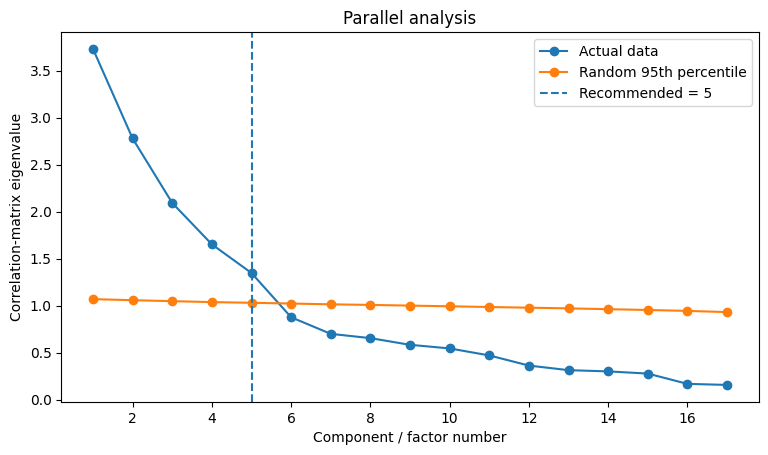

In [9]:
X = D[FEATURES_SELECTED].apply(pd.to_numeric, errors="coerce").copy()

for f in LOG1P_FIELDS.intersection(X.columns):
    if (X[f].dropna() < 0).any():
        raise ValueError(f"{f} has negative values but is declared log1p.")
    X[f] = np.log1p(X[f])

degenerate = [
    f for f in X.columns
    if X[f].notna().sum() == 0 or X[f].dropna().nunique() <= 1
]
if degenerate:
    print("Dropped degenerate fields:", degenerate)
    X = X.drop(columns=degenerate)

medians = X.median()
if medians.isna().any():
    raise ValueError(f"Entirely missing fields remain: {medians[medians.isna()].index.tolist()}")

X = X.fillna(medians)
Z = StandardScaler().fit_transform(X)


def parallel_analysis(Z, iterations=PARALLEL_ITERATIONS, sample_n=PARALLEL_SAMPLE_N, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n, p = Z.shape
    actual_corr = np.corrcoef(Z, rowvar=False)
    actual = np.linalg.eigvalsh(actual_corr)[::-1]

    n_sim = min(n, sample_n)
    random_eigs = np.empty((iterations, p))
    for i in range(iterations):
        R = rng.normal(size=(n_sim, p))
        random_eigs[i] = np.linalg.eigvalsh(np.corrcoef(R, rowvar=False))[::-1]

    threshold = np.quantile(random_eigs, 0.95, axis=0)
    recommended = int(np.sum(actual > threshold))
    return actual, threshold, max(1, recommended)


ACTUAL_EIGS, RANDOM_95, PARALLEL_RECOMMENDED = parallel_analysis(Z)
N_FACTORS = N_FACTORS_OVERRIDE or PARALLEL_RECOMMENDED
N_FACTORS = min(max(1, int(N_FACTORS)), Z.shape[1] - 1)

print(f"Parallel-analysis recommendation: {PARALLEL_RECOMMENDED} factors")
print(f"Factor solution being fit: {N_FACTORS}")

x_axis = np.arange(1, len(ACTUAL_EIGS) + 1)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x_axis, ACTUAL_EIGS, marker="o", label="Actual data")
ax.plot(x_axis, RANDOM_95, marker="o", label="Random 95th percentile")
ax.axvline(PARALLEL_RECOMMENDED, linestyle="--", label=f"Recommended = {PARALLEL_RECOMMENDED}")
ax.set_xlabel("Component / factor number")
ax.set_ylabel("Correlation-matrix eigenvalue")
ax.set_title("Parallel analysis")
ax.legend()
plt.show()


## 4 - Fit one EFA + read the result

The factor solution uses **varimax rotation** for easier interpretation.

The main output is:
- one compact card per factor showing its strongest loadings;
- one feature-audit table showing each feature's primary factor and whether it cross-loads;
- an expandable full loading matrix for detail.

**Important:** factor signs are arbitrary. The notebook flips each factor so its largest loading is positive purely for readability.


In [5]:
fa = FactorAnalysis(
    n_components=N_FACTORS,
    rotation="varimax",
    random_state=RANDOM_STATE,
)
fa.fit(Z)

loadings = pd.DataFrame(
    fa.components_.T,
    index=X.columns,
    columns=[f"F{i}" for i in range(1, N_FACTORS + 1)],
)

for col in loadings.columns:
    idx = loadings[col].abs().idxmax()
    if loadings.loc[idx, col] < 0:
        loadings[col] *= -1

ss = (loadings ** 2).sum(axis=0)
order = ss.sort_values(ascending=False).index.tolist()
loadings = loadings[order]
loadings.columns = [f"F{i}" for i in range(1, N_FACTORS + 1)]

ss = (loadings ** 2).sum(axis=0)
variance_share = ss / loadings.shape[0]
communality = (loadings ** 2).sum(axis=1)


def pretty_feature(f):
    return f.replace("_24m", "").replace("_12m", "").replace("_", " ")


summary_rows = []
for factor in loadings.columns:
    s = loadings[factor].sort_values(key=np.abs, ascending=False)
    top = s.head(5)
    summary_rows.append({
        "factor": factor,
        "SS_loading": ss[factor],
        "variance_share": variance_share[factor],
        "top_loadings": " | ".join(f"{pretty_feature(f)} ({v:+.2f})" for f, v in top.items()),
    })

FACTOR_SUMMARY = pd.DataFrame(summary_rows)

cards = []
for r in FACTOR_SUMMARY.itertuples(index=False):
    cards.append(
        f"""<div style="border:1px solid #d1d5db;border-radius:8px;padding:12px 14px;margin:9px 0;background:#fff">
          <div style="font-size:18px;font-weight:700">{escape(r.factor)}</div>
          <div style="font-size:12px;color:#555;margin:2px 0 8px 0">
            SS loading {r.SS_loading:.2f} | approx. {r.variance_share:.1%} of standardized variance
          </div>
          <div style="font-size:13px;line-height:1.55">{escape(r.top_loadings)}</div>
        </div>"""
    )
display(HTML("".join(cards)))

audit = []
for feature in loadings.index:
    row = loadings.loc[feature]
    ranked = row.abs().sort_values(ascending=False)
    primary = ranked.index[0]
    second = ranked.index[1] if len(ranked) > 1 else None
    primary_loading = row[primary]
    second_loading = row[second] if second is not None else np.nan
    cross = (
        abs(primary_loading) >= CROSS_LOADING_THRESHOLD
        and pd.notna(second_loading)
        and abs(second_loading) >= CROSS_LOADING_THRESHOLD
    )
    audit.append({
        "concept": group_lookup.get(feature, ""),
        "feature": feature,
        "primary_factor": primary,
        "primary_loading": primary_loading,
        "second_factor": second,
        "second_loading": second_loading,
        "communality": communality[feature],
        "cross_load": "YES" if cross else "",
    })

FEATURE_AUDIT = pd.DataFrame(audit)
factor_num = {f: i for i, f in enumerate(loadings.columns)}
FEATURE_AUDIT["_sort"] = FEATURE_AUDIT["primary_factor"].map(factor_num)
FEATURE_AUDIT = FEATURE_AUDIT.sort_values(["_sort", "primary_loading"], ascending=[True, False]).drop(columns="_sort")

display(
    FEATURE_AUDIT.style
    .format({
        "primary_loading": "{:+.2f}",
        "second_loading": "{:+.2f}",
        "communality": "{:.2f}",
    })
    .hide(axis="index")
    .set_caption("Feature audit - cross-load = |loading| >= .30 on at least two factors")
)


def fmt_loading(v):
    return "" if abs(v) < LOADING_DISPLAY_THRESHOLD else f"{v:+.2f}"


matrix_html = loadings.map(fmt_loading).to_html(escape=False)
display(HTML(
    f"""<details style="margin-top:12px">
      <summary style="cursor:pointer;font-weight:700">Show full loading matrix (|loading| >= {LOADING_DISPLAY_THRESHOLD:.2f})</summary>
      <div style="margin-top:8px;overflow-x:auto">{matrix_html}</div>
    </details>"""
))

TOTAL_COMMON_VARIANCE = communality.mean()
print(f"Average communality across selected features: {TOTAL_COMMON_VARIANCE:.2f}")
print("Done. To iterate: change FEATURE_GROUPS or N_FACTORS_OVERRIDE, then rerun all.")


/opt/miniconda3/lib/python3.13/site-packages/sklearn/decomposition/_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(


concept,feature,primary_factor,primary_loading,second_factor,second_loading,communality,cross_load
amount_style,share_gifts_round_amount_24m,F1,+0.90,F8,-0.20,0.89,
amount_style,modal_amount_share_24m,F1,+0.74,F7,-0.21,0.65,
funding_posture,share_gifts_first_money_in_24m,F1,+0.43,F8,-0.15,0.26,
platform_support,avg_optional_donation_rate_24m,F1,+0.32,F3,+0.28,0.33,
relationship,share_gifts_repeat_teacher_24m,F2,+0.91,F6,+0.11,0.86,
choice_breadth,entropy_category_norm_24m,F2,-0.26,F7,-0.20,0.19,
relationship,entropy_school_norm_24m,F2,-0.65,F1,-0.27,0.57,
amount_style,median_gift_amount_24m,F3,+0.94,F8,+0.18,0.94,
funding_posture,median_gift_to_project_cost_ratio_24m,F3,+0.59,F1,-0.56,0.69,YES
site_engagement,days_with_site_activity_24m,F4,+0.84,F6,+0.33,0.83,YES


,F1,F2,F3,F4,F5,F6,F7,F8
n_active_months_24m,,,,+0.39,,+0.83,,
gifts_per_active_month_24m,-0.31,,,,,,+0.84,
share_gifts_repeat_teacher_24m,,+0.91,,,,,,
entropy_school_norm_24m,,-0.65,,,,,,
modal_amount_share_24m,+0.74,,,,,,,
share_gifts_round_amount_24m,+0.90,,,,,,,
median_gift_amount_24m,,,+0.94,,,,,
median_gift_to_project_cost_ratio_24m,-0.56,,+0.59,,,,,
share_gifts_first_money_in_24m,+0.43,,,,,,,
share_gifts_closed_project_24m,-0.34,,,,,,,+0.82


Average communality across selected features: 0.68
Done. To iterate: change FEATURE_GROUPS or N_FACTORS_OVERRIDE, then rerun all.
